In [1]:
import torch
from torch.utils.data import Dataset,  DataLoader

import os
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor, Lambda
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
matplotlib.use('Agg')
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
import torch
print(torch.cuda.is_available())

True


# Sample data from pytorch

In [4]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
   # target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    #target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

# Dataloaders

In [6]:
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True, )
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

In [7]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


In [8]:
img = train_features[0].squeeze().cpu()
label = train_labels[0].cpu()

In [9]:
%matplotlib inline

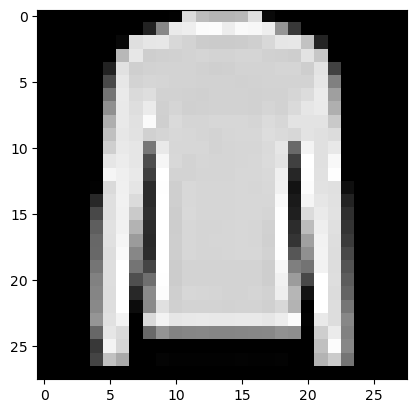

Label: 2


In [10]:
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

# Neural network

In [12]:
import os
from torch import nn

We want to be able to train our model on an accelerator such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

In [14]:

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [15]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        #self.flatten = nn.Flatten()
        self.conv_relu_stack = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # input: 1x28x28 → 32x28x28
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1), # 32x28x28 → 32x28x28
            nn.ReLU(),
            nn.Flatten(),  # flatten 32*28*28 = 25088
            nn.Linear(32*28*28, 10)
        )

    def forward(self, x):
        #x = self.flatten(x)
        logits = self.conv_relu_stack(x)
        return logits

In [16]:
model = CNN().to(device)
print(model)

CNN(
  (conv_relu_stack): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=25088, out_features=10, bias=True)
  )
)


# Automatic Differentiation with torch.autograd

In [45]:
learning_rate = 1e-4
batch_size = 64
epochs = 5

In [47]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    total_loss=0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    avg_loss = total_loss / len(dataloader)
    return avg_loss


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    
    
    return test_loss, correct

In [49]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_loss_list=[]
test_loss_list=[]
test_accuracy_list=[]
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    avg_loss=train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, correct=test_loop(test_dataloader, model, loss_fn)

    train_loss_list.append(avg_loss)
    test_loss_list.append(test_loss)
    test_accuracy_list.append(correct)
print("Done!")

Epoch 1
-------------------------------
loss: 0.393075  [   64/60000]
loss: 0.480762  [ 6464/60000]
loss: 0.393987  [12864/60000]
loss: 0.444503  [19264/60000]
loss: 0.425470  [25664/60000]
loss: 0.541851  [32064/60000]
loss: 0.460292  [38464/60000]
loss: 0.570723  [44864/60000]
loss: 0.399014  [51264/60000]
loss: 0.515080  [57664/60000]
Test Error: 
 Accuracy: 82.8%, Avg loss: 0.476309 

Epoch 2
-------------------------------
loss: 0.490807  [   64/60000]
loss: 0.337883  [ 6464/60000]
loss: 0.438007  [12864/60000]
loss: 0.545796  [19264/60000]
loss: 0.327677  [25664/60000]
loss: 0.221964  [32064/60000]
loss: 0.387955  [38464/60000]
loss: 0.387603  [44864/60000]
loss: 0.375436  [51264/60000]
loss: 0.476608  [57664/60000]
Test Error: 
 Accuracy: 83.1%, Avg loss: 0.474529 

Epoch 3
-------------------------------
loss: 0.399496  [   64/60000]
loss: 0.467970  [ 6464/60000]
loss: 0.545844  [12864/60000]
loss: 0.528691  [19264/60000]
loss: 0.370061  [25664/60000]
loss: 0.404100  [32064/600

# Metrics

Text(0.5, 0, 'Epoch')

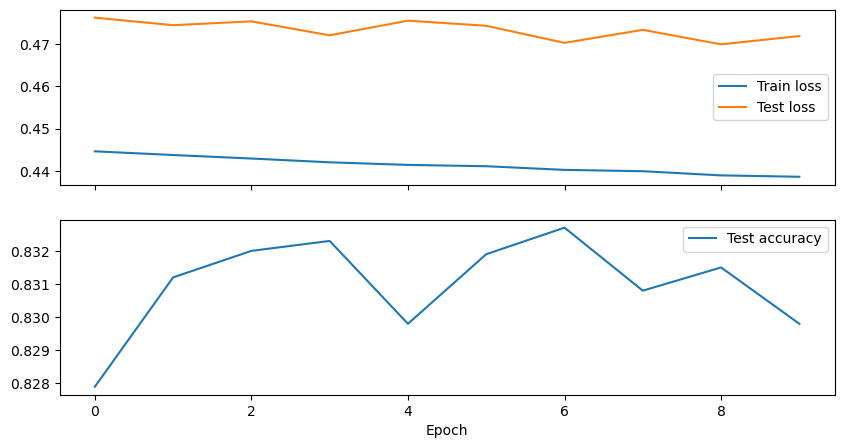

In [51]:
fig, ax =plt.subplots(figsize=(10,5),nrows=2, sharex=True)

ax[0].plot(train_loss_list, label='Train loss')
ax[0].plot(test_loss_list, label='Test loss')
ax[0].legend()

ax[1].plot(test_accuracy_list, label='Test accuracy')
ax[1].legend()
ax[1].set_xlabel('Epoch')

In [53]:
def get_all_preds_and_labels(dataloader, model, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            preds = model(X).argmax(1).cpu()  # get predicted classes
            all_preds.extend(preds)
            all_labels.extend(y)

    return torch.tensor(all_preds), torch.tensor(all_labels)

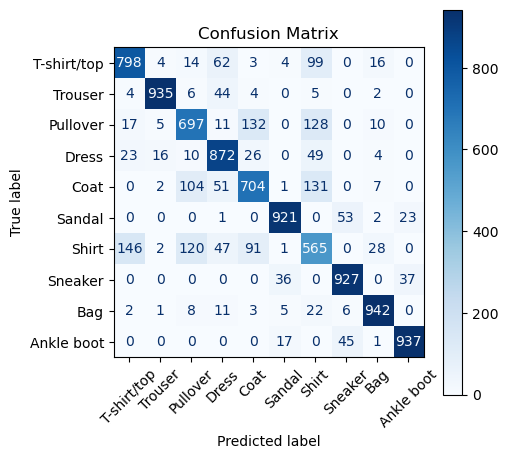

In [55]:
# Get predictions
preds, labels = get_all_preds_and_labels(test_dataloader, model, device)

# Compute confusion matrix
cm = confusion_matrix(labels, preds)
%matplotlib inline
# Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=training_data.classes)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title("Confusion Matrix")
plt.show()